# FDA 有害事象報告データ — 相関と構造変化（分析ノートブック）

このノートブックは分析の**ロジックと結果**を通しで示すものです。
4パネルの作図コードは `src/` に置き、ここでは統計量の計算と結論に集中します。

- 分析1: Total Reports × Expedited（部分-全体の交絡）
- 分析2: Expedited × Non-Expedited（独立な内訳同士・偏相関）
- 分析3: 構造変化の検出（変化点検定）

> データ: FDA FAERS Public Dashboard（パブリックドメイン）。件数の集計であり因果の証拠ではない。

In [1]:
import sys
import numpy as np
from scipy import stats
sys.path.insert(0, "src")          # リポジトリ相対で src を解決
import common as C

df = C.load_clean()                 # 集計行除外・"-"→NaN・型変換
print("shape:", df.shape, "/ 年:", int(df['Year'].min()), "-", int(df['Year'].max()))
df[["Year", "Total Reports", "Expedited", "Non-Expedited", "Direct"]].head()

shape: (59, 8) / 年: 1968 - 2026


,Year,Total Reports,Expedited,Non-Expedited,Direct
0,1968,107,NaN,98,9
1,1969,5433,1.0,2745,2687
2,1970,17947,5.0,9979,7963
3,1971,13156,1.0,8238,4917
4,1972,9637,NaN,7603,2034


## 分析1: Total Reports と Expedited

強い相関が出るが、**Expedited は Total の構成要素**なので半ば定義的。年トレンドも共通する。

In [2]:
d = df.dropna(subset=["Total Reports", "Expedited"])
x = d["Total Reports"].to_numpy(float)
y = d["Expedited"].to_numpy(float)
yr = d["Year"].to_numpy(float)

r, p = stats.pearsonr(x, y)
print(f"Pearson r = {r:.4f}  (p={p:.1e})")

# 部分-全体の検算: Total = 各カテゴリの合計 か
comp = df[C.CATEGORIES].fillna(0).sum(axis=1)
print(f"Total = 各カテゴリ合計 の成立率: {np.isclose(comp, df['Total Reports']).mean():.0%}")

# 年トレンドを除去した偏相関
detrend = lambda v, t: v - np.polyval(np.polyfit(t, v, 1), t)
pr, _ = stats.pearsonr(detrend(x, yr), detrend(y, yr))
print(f"偏相関（年を制御） r = {pr:.4f}")

Pearson r = 0.9962  (p=5.1e-58)
Total = 各カテゴリ合計 の成立率: 100%
偏相関（年を制御） r = 0.9876


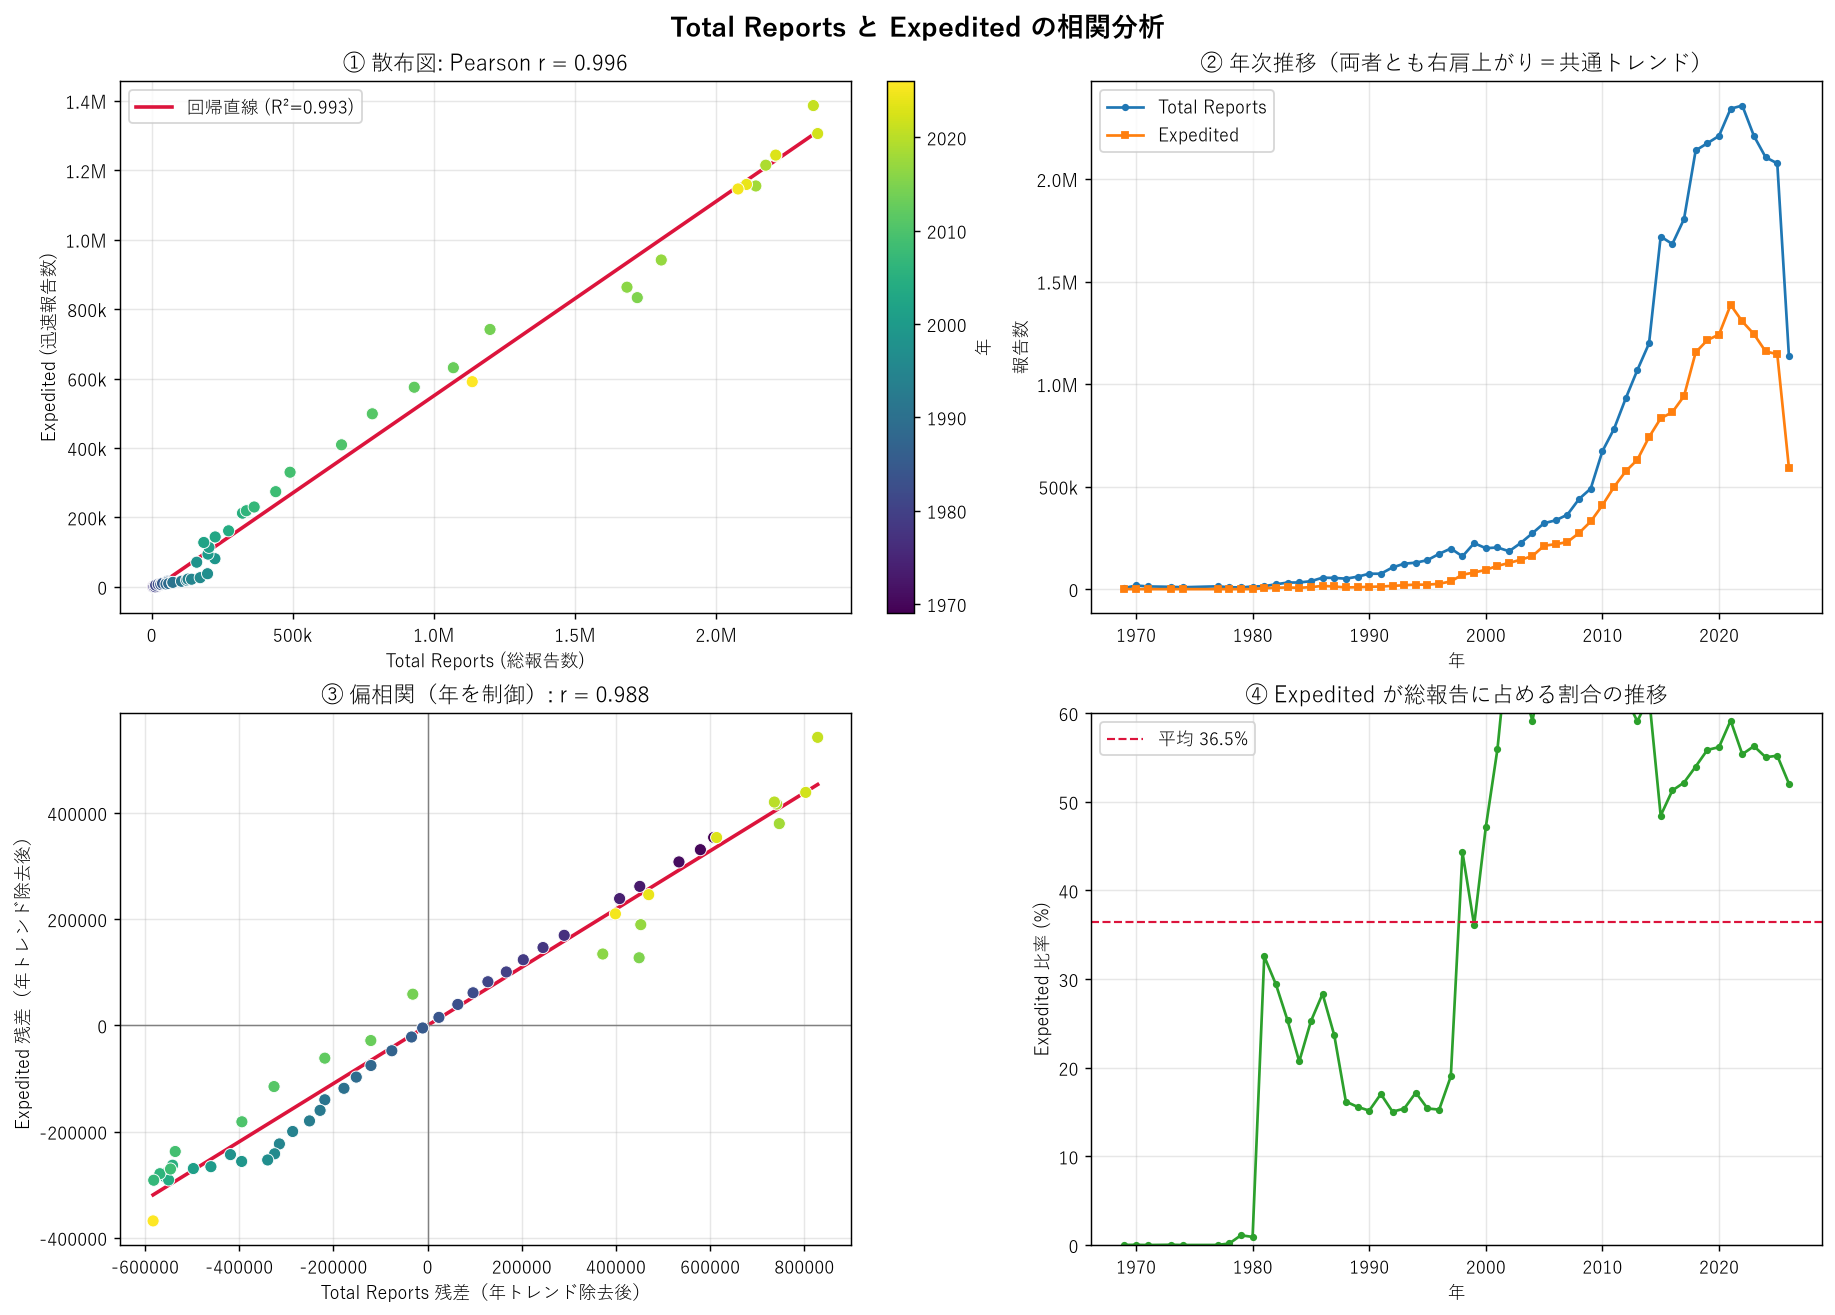

In [3]:
from IPython.display import Image
Image(str(C.FIG_DIR / "01_total_vs_expedited.png"))

## 分析2: Expedited と Non-Expedited（独立な内訳同士）

互いに他方を含まない。年を制御しても相関が残れば、**時間以外の共通要因**を示唆する
（ただし相関は因果ではない）。

In [4]:
d2 = df.dropna(subset=["Expedited", "Non-Expedited"])
e = d2["Expedited"].to_numpy(float)
ne = d2["Non-Expedited"].to_numpy(float)
yr2 = d2["Year"].to_numpy(float)

print(f"Pearson r = {stats.pearsonr(e, ne)[0]:.4f}")
pr2, _ = stats.pearsonr(detrend(e, yr2), detrend(ne, yr2))
print(f"偏相関（年を制御） r = {pr2:.4f}")

ratio = e / ne
first_cross = int(d2.loc[ratio >= 1.0, "Year"].min())
print(f"迅速/非迅速 比: 平均 {ratio.mean():.2f} / 迅速が逆転した年: {first_cross}")

Pearson r = 0.9771
偏相関（年を制御） r = 0.9309
迅速/非迅速 比: 平均 0.97 / 迅速が逆転した年: 2000


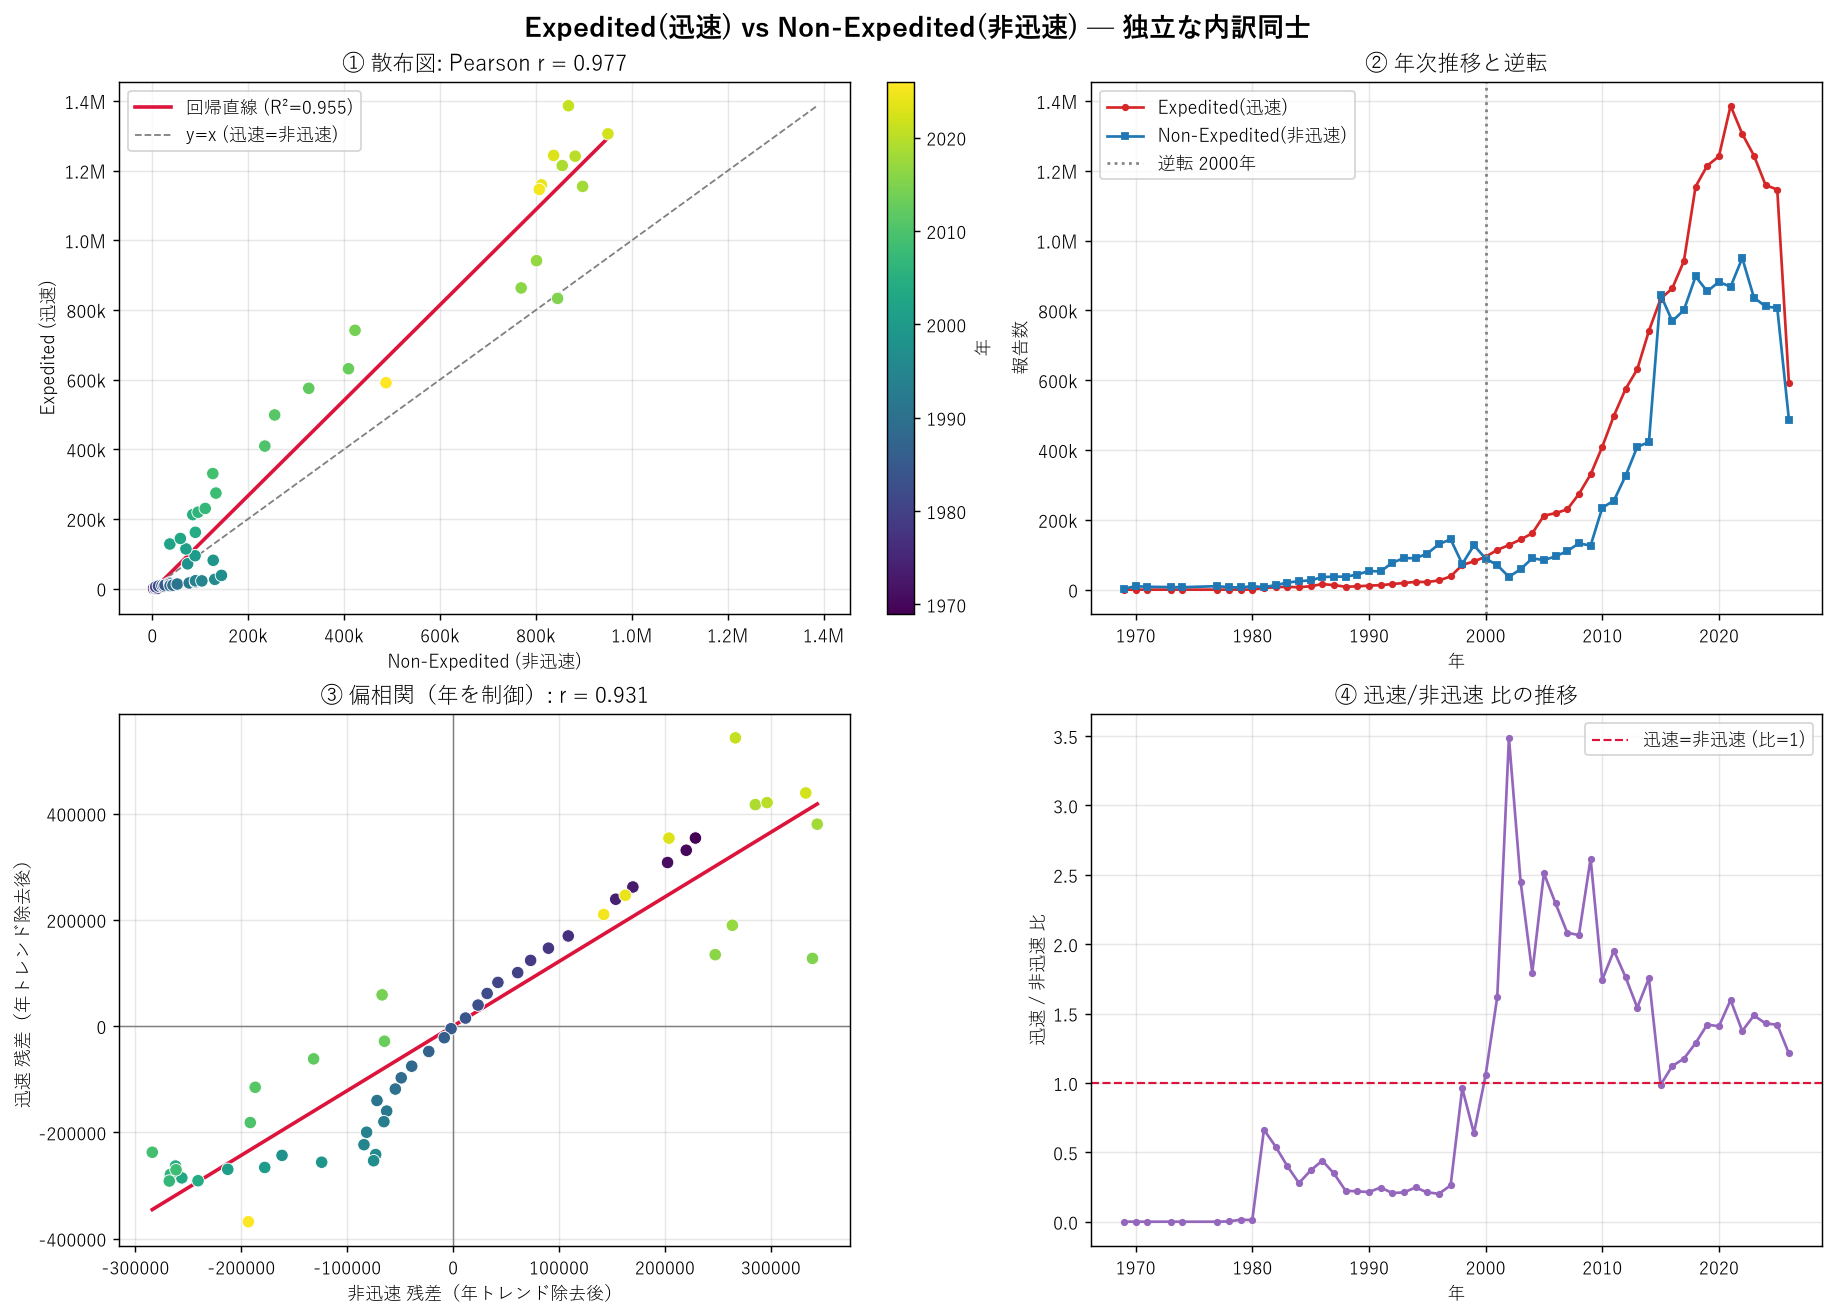

In [5]:
Image(str(C.FIG_DIR / "02_expedited_vs_nonexpedited.png"))

## 分析3: 構造変化の検出（変化点検定）

迅速シェア（Expedited/Total）に、動的計画法によるピースワイズ定数分割（l2コスト）を適用。
`src/03_structural_change.py` の `best_partition` を読み込んで使う。

In [6]:
import importlib.util
spec = importlib.util.spec_from_file_location("sc", "src/03_structural_change.py")
sc = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sc)   # 関数定義のみ実行（main は __name__ ガードで動かない）

dfc = df.copy()
for c in C.CATEGORIES:
    dfc[c] = dfc[c].fillna(0.0)
share = (dfc["Expedited"] / dfc["Total Reports"]).to_numpy(float)
years = dfc["Year"].to_numpy(float)

res = sc.best_partition(share, kmax=4)
print(" k |    SSE   | 変化年")
for k, (sse, bps) in res.items():
    print(f" {k} | {sse:7.3f} | {[int(years[b]) for b in bps]}")
print("\n=> SSEのエルボー(k=3)で採用: 変化年 =", [int(years[b]) for b in res[3][1]])

 k |    SSE   | 変化年
 1 |   3.564 | []
 2 |   0.507 | [1998]
 3 |   0.206 | [1981, 1998]
 4 |   0.134 | [1981, 1998, 2001]

=> SSEのエルボー(k=3)で採用: 変化年 = [1981, 1998]


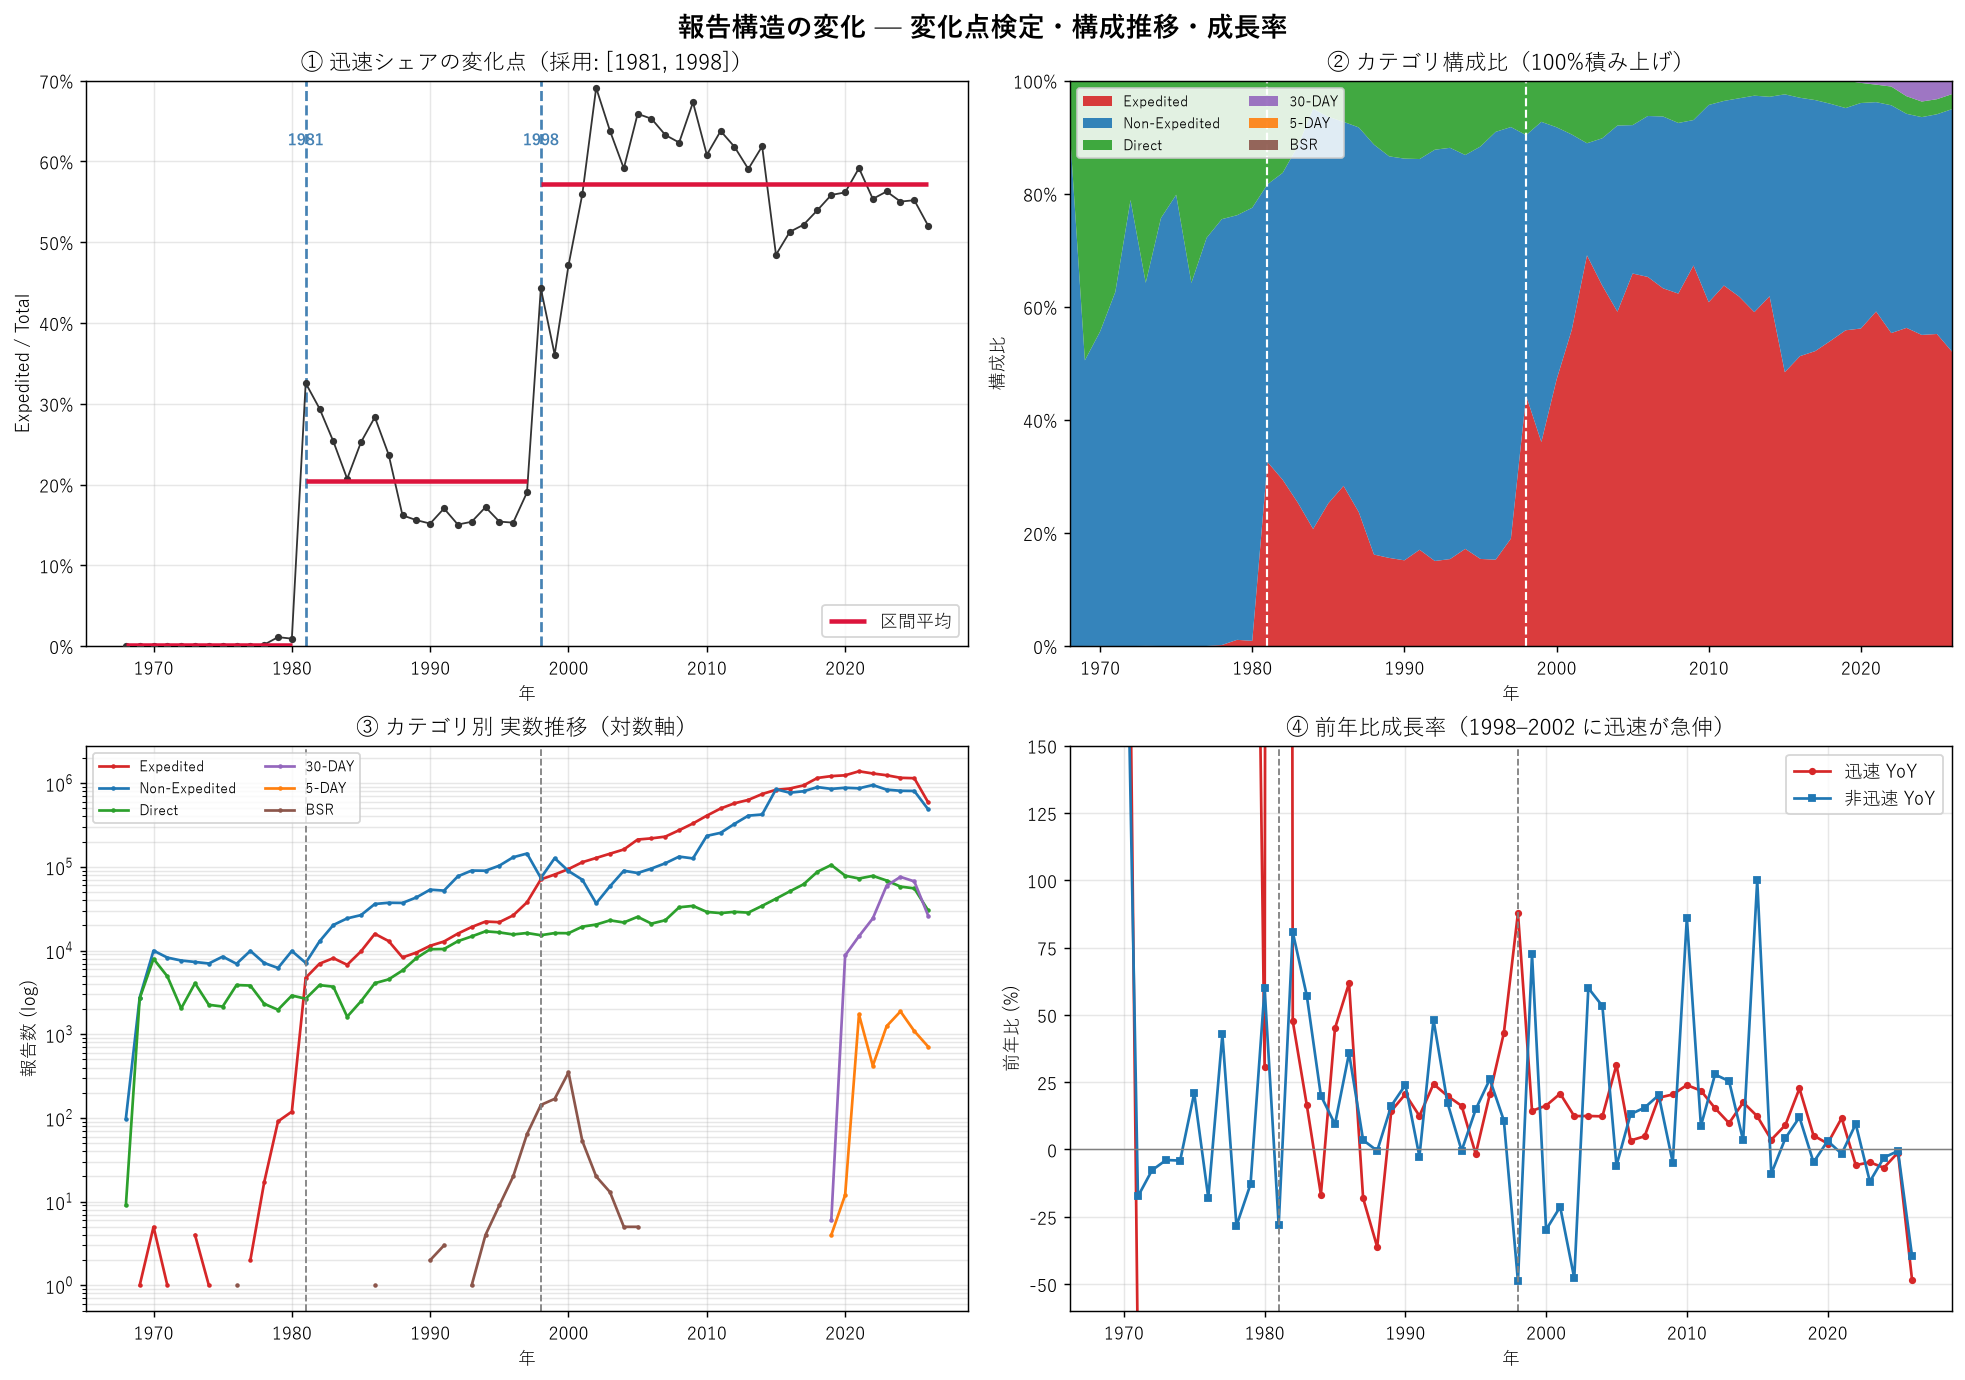

In [7]:
Image(str(C.FIG_DIR / "03_structural_change.png"))

## 考察（要点）

- **相関→偏相関**: 迅速×非迅速は年制御後も r≈0.93。時間以外の**共通要因**が両者を同時に動かす可能性。
  ただし**相関は因果ではない**。消せたのは「時間」という1つの交絡だけで、方向は特定できない。
- **水準と割合の区別**: 「薬剤・利用者が増えて両方の件数が増えた」は**実数**は説明できるが、
  **迅速シェアの上昇（0.2%→57%）は説明できない**。シェア上昇には迅速が非迅速より速く増える必要があり、
  **迅速に固有の要因（報告制度・基準の変更など）**を示唆する。
- **構造変化**: 1981年・1998年に転換。持続的な水準シフトであり、単一薬剤による一時的スパイクとは形が異なる。

### 限界
相関≠因果 / 2026年は年途中の暫定値 / 変化点はモデル選択に依存（BICは過分割）/ 集計データゆえ層別不可。

詳細は [README](README.md) を参照。